In [832]:
# --- IMPORT STATEMENTS ---

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.odr import ODR, Model, Data
from scipy import constants
from scipy.stats import spearmanr

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import Gaussian2DKernel, convolve

In [833]:
# --- GLOBAL VARIABLES ---
SAVE_FIGS = True
MASKED = True

L_BOUNDS = [16, 32] # degrees
B_BOUNDS = [-1.1, 1.1] # degrees

DEGREES_PER_REGION = 2.2 # for lattice TT plots (change as desired)

SMOOTHING_FWHM = 5 # arcmin
REBIN_FACTOR = 5

# LINUX_DIRECTORY = '/home/aimee/mphys' # Aimee
LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/maps' # Aimee
MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/maps' # Joe
# MASKED_MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/masked_maps' # Aimee
MASKED_MAPS_DIRECTORY = f'{LINUX_DIRECTORY}/data/all_maps/masked_maps' # Joe
# FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures' # Aimee
FIGURE_SAVEDIR = f'{LINUX_DIRECTORY}/figures/maps_and_TTplots' # Joe

# MAPS

# Beam widths? (GET TRUE VALUES FOR ALL MAPS)
COMAP_FWHM = 4.5
EFFELSBERG_FWHM = 4.9999
GDIGS_FWHM = 4.9999 # TEMP
NOBEYAMA_FWHM = 4.9999 # TEMP
PARKES_FWHM = 4.9999 # TEMP
SINO_GERMAN_FWHM = 4.9999 # TEMP
AKARI_FWHM = 4.9999 # TEMP

# Fractional errors (GET TRUE VALUES FOR ALL MAPS)
COMAP_ERR = 0.05
EFFELSBERG_ERR = 0.1
GDIGS_ERR = 0.1 # TEMP - CHECK!
NOBEYAMA_ERR = 0.1 # TEMP
PARKES_ERR = 0.1 # TEMP
SINO_GERMAN_ERR = 0.1 # TEMP
AKARI_ERR = 0.1 # TEMP

# Maps and their frequencies

COMAP_MAPS = { # name : [file name, frequency / Hz]
    "COMAP 26.5 GHz" : ["comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 26.5e9],
    "COMAP 27.5 GHz" : ["comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 27.5e9],
    "COMAP 28.5 GHz" : ["comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 28.5e9],
    "COMAP 29.5 GHz" : ["comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 29.5e9],
    "COMAP 30.5 GHz" : ["comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 30.5e9],
    "COMAP 31.5 GHz" : ["comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 31.5e9],
    "COMAP 32.5 GHz" : ["comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 32.5e9],
    "COMAP 33.5 GHz" : ["comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits", 33.5e9]
}

# User guide: https://eff100mwiki.mpifr-bonn.mpg.de/doku.php?id=information_for_astronomers:user_guide:index
EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    # "Effelsberg 1.43 GHz (10')" : ["EFFELSBERG-1.4285714285714286GHz-10.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (15')" : ["EFFELSBERG-1.4285714285714286GHz-15.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (20')" : ["EFFELSBERG-1.4285714285714286GHz-20.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (25')" : ["EFFELSBERG-1.4285714285714286GHz-25.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (30')" : ["EFFELSBERG-1.4285714285714286GHz-30.0amin.fits", 1.4285714285714286e9],
    # "Effelsberg 1.43 GHz (60')" : ["EFFELSBERG-1.4285714285714286GHz-60.0amin.fits", 1.4285714285714286e9],
    "Effelsberg 2.73 GHz (5 amin)" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (10')" : ["EFFELSBERG-2.7272727272727275GHz-10.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (15')" : ["EFFELSBERG-2.7272727272727275GHz-15.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (20')" : ["EFFELSBERG-2.7272727272727275GHz-20.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (25')" : ["EFFELSBERG-2.7272727272727275GHz-25.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (30')" : ["EFFELSBERG-2.7272727272727275GHz-30.0amin.fits", 2.7272727272727275e9],
    # "Effelsberg 2.73 GHz (60')" : ["EFFELSBERG-2.7272727272727275GHz-60.0amin.fits", 2.7272727272727275e9]
}

GDIGS_MAPS = { # name : [file name, frequency / Hz]
    # Note to self: create a GDIGS mosaic smoothed to 5 arcmin?
    "GDIGS Moment 0" : ["gdigs_moment0_mosaic.fits", 5.7e9] # CHECK GDIGS FREQUENCY
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
    "Nobeyama 10.0GHz (5 amin)" : ["NOBEYAMA-10.0GHz-5.0amin.fits", 10e9]
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    # "PARKES 5GHz (5')" : ["PARKES-5.0GHz-5.0amin.fits", 5e9], # CORRUPTED
    # "PARKES 5GHz (10')" : ["PARKES-5.0GHz-10.0amin.fits", 5e9]
}

SINO_GERMAN_MAPS = { # name : [file name, frequency / Hz]
    "Sino German 5.0GHz (5 amin)" : ["SinoGermanSurvey-5.0GHz-10.0amin.fits", 5e9]
}

AKARI_MAPS = { # name : [file name, frequency / Hz]
    "Akari 1875 GHz (5 amin)" : ["AKARI-1874.9999999999998GHz-5.0amin.fits", 1874.9999999999998e9],
    # "Akari 1875 GHz (10')" : ["AKARI-1874.9999999999998GHz-10.0amin.fits", 1874.9999999999998e9],
    "Akari 2143 GHz (5 amin)" : ["AKARI-2142.857142857143GHz-5.0amin.fits", 2142.857142857143e9],
    # "Akari 2143 GHz (10')" : ["AKARI-2142.857142857143GHz-10.0amin.fits", 2142.857142857143e9],
    "Akari 3333 GHz (5 amin)" : ["AKARI-3333.333333333333GHz-5.0amin.fits", 3333.333333333333e9],
    # "Akari 3333 GHz (10')" : ["AKARI-3333.333333333333GHz-10.0amin.fits", 3333.333333333333e9],
    "Akari 4615 GHz (5 amin)" : ["AKARI-4615.384615384616GHz-5.0amin.fits", 4615.384615384616e9],
    # "Akari 4615 GHz (10')" : ["AKARI-4615.384615384616GHz-10.0amin.fits", 4615.384615384616e9]
}

AMI_MAPS = {}

BOLOCAM_MAPS = {} # CORRUPTED

CGPS_MAPS = {} # CORRUPTED

CHIPASS_MAPS = {}

IRIS_MAPS = {}


In [834]:
# --- FUNCTION DEFINITIONS ---

In [835]:
# --- MAPS PROCESSING ---

In [836]:
def get_map(path):
    
    # print(f"\nGetting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, header, wcs

In [837]:
def get_map_info(map_title):
    
    if map_title in COMAP_MAPS.keys():
        fname = COMAP_MAPS[map_title][0]
        freq = COMAP_MAPS[map_title][1]
        fwhm = COMAP_FWHM
        err = COMAP_ERR
    elif map_title in EFFELSBERG_MAPS.keys():
        fname = EFFELSBERG_MAPS[map_title][0]
        freq = EFFELSBERG_MAPS[map_title][1]
        fwhm = EFFELSBERG_FWHM
        err = EFFELSBERG_ERR
    elif map_title in GDIGS_MAPS.keys():
        fname = GDIGS_MAPS[map_title][0]
        freq = GDIGS_MAPS[map_title][1]
        fwhm = GDIGS_FWHM
        err = GDIGS_ERR
    elif map_title in NOBEYAMA_MAPS.keys():
        fname = NOBEYAMA_MAPS[map_title][0]
        freq = NOBEYAMA_MAPS[map_title][1]
        fwhm = NOBEYAMA_FWHM # FIND OUT!
        err = NOBEYAMA_ERR # FIND OUT!
    elif map_title in PARKES_MAPS.keys():
        fname = PARKES_MAPS[map_title][0]
        freq = PARKES_MAPS[map_title][1]
        fwhm = PARKES_FWHM # FIND OUT!
        err = PARKES_ERR # FIND OUT!
    elif map_title in SINO_GERMAN_MAPS.keys():
        fname = SINO_GERMAN_MAPS[map_title][0]
        freq = SINO_GERMAN_MAPS[map_title][1]
        fwhm = SINO_GERMAN_FWHM # FIND OUT!
        err = SINO_GERMAN_ERR # FIND OUT!
    elif map_title in AKARI_MAPS.keys():
        fname = AKARI_MAPS[map_title][0]
        freq = AKARI_MAPS[map_title][1]
        fwhm = AKARI_FWHM # FIND OUT!
        err = AKARI_ERR # FIND OUT!
    
    # (ADD MORE MAPS AS NECESSARY)
    
    else:
        print(f'Error extracting map details for {map_title}')
        return None, None, None, None

    return fname, freq, fwhm, err

In [838]:
def convert_to_mK(map_title, map, map_freq):
    
    # COMAP and GDIGS in K
    if map_title in COMAP_MAPS.keys() or map_title in GDIGS_MAPS.keys():
        map_mK = np.array(map) * 1000 # K to mK 
    
    # All other maps in Jy/sr (CHECK WHENEVER ADD NEW MAPS!)
    else: 
        map_K = JyPersr_to_K(np.array(map), map_freq) # Jy/sr to K
        map_mK = np.array(map_K) * 1000 # K to mK
    
    return map_mK

In [839]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = -0.01 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [840]:
def cut_data(data, wcs, header, l_bounds=L_BOUNDS, b_bounds=B_BOUNDS):
    
    lat_min, lat_max = b_bounds[0], b_bounds[1]
    long_min, long_max = l_bounds[0], l_bounds[1]

    step = header['CDELT2']  # pixel resolution

    # may be off by fraction of pixel
    start_row = int(header['CRPIX2'] + lat_min / step)
    end_row   = int(header['CRPIX2'] + lat_max / step)
    start_col = int(header['CRPIX1'] + (header['CRVAL1'] - long_max) / step)
    end_col   = int(header['CRPIX1'] + (header['CRVAL1'] - long_min) / step)
    
    # Safety check against invalid indices
    nrows, ncols = data.shape
    
    start_row = max(0, min(nrows - 1, start_row))
    end_row   = max(0, min(nrows - 1, end_row))
    start_col = max(0, min(ncols - 1, start_col))
    end_col   = max(0, min(ncols - 1, end_col))
    
    # Extract and process submap
    submap = data[start_row:end_row + 1, start_col:end_col + 1].copy()
    submap[submap == 0] = np.nan

    wcs.wcs.crpix[0] -= start_col
    wcs.wcs.crpix[1] -= start_row


    header['CRPIX1'] = wcs.wcs.crpix[0]
    header['CRPIX2'] = wcs.wcs.crpix[1]
    
    return submap, wcs, header






In [841]:
def rebin_array(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data


def rebin_map(data, wcs, header, factor):
    
    l_min = L_BOUNDS[0]
    l_max = L_BOUNDS[1]
    b_min = B_BOUNDS[0]
    b_max = B_BOUNDS[1]
    step = wcs.wcs.cdelt[1] # pixel size in degrees

    data = rebin_array(data, factor)

    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    # Indices for cutout
    wcs.wcs.crpix[0] = cx
    wcs.wcs.crpix[1] = cy
    wcs.wcs.cdelt[0] = -step * factor
    wcs.wcs.cdelt[1] = step * factor
    wcs.wcs.crval[0] = (l_min + l_max) / 2
    wcs.wcs.crval[1] = (b_min + b_max) / 2

    header = wcs.to_header()

    return data, wcs, header

In [842]:
def JyPersr_to_K(inp, freq):
    
    k_B = constants.Boltzmann
    c = constants.speed_of_light
    Jy_to_SI = 1e-26

    factor = (c**2) / (2 * k_B * (freq**2)) * Jy_to_SI
    
    return factor * inp

In [843]:
def sigma(FWHM1, FWHM2, scale):
    
    sigma = np.sqrt(abs(FWHM1**2 - FWHM2**2)) / (2*np.sqrt(2 * np.log(2)) * scale)
    
    return sigma

In [844]:
def process_map(map_title, masked=True):
    
    map_fname, map_freq, map_fwhm, map_err = get_map_info(map_title)

    if masked:
        map, header, wcs = get_map(f'{MASKED_MAPS_DIRECTORY}/{map_fname.replace(".fits", "")}_masked.fits')
        # plot_fits(map, wcs, title=f'{map_title} - masked')
    else:
        map, header, wcs = get_map(f'{MAPS_DIRECTORY}/{map_fname}')
        # plot_fits(map, wcs, title=f'{map_title} - original')
    
    # Convert to brigtness temperature [mK]
    map = convert_to_mK(map_title, map, map_freq)

    if masked: # Mask values < 0 (Note to self: add brightness threshold in maksing code -> unnecessary?)
        threshold = 0 # mK
        map[np.where(map <= threshold)] = np.nan

    # Cut data to size
    map, wcs, header = cut_data(map, wcs, header)
    # plot_fits(map, wcs, title=f'{map_title} - cut')

    # Smooth to 5 arcmin (doesn't change wcs/header)
    smoothing_kernel = Gaussian2DKernel(x_stddev=sigma(map_fwhm, SMOOTHING_FWHM, 1))
    map_smooth = convolve(map, smoothing_kernel, preserve_nan=True)
    # plot_fits(map_smooth, wcs, title=f'{map_title} - smoothed to 5 arcmin')

    # Repixellise to 5x5 bins (does change wcs/header)
    map_repix, map_repix_wcs, map_repix_header = rebin_map(map_smooth, wcs, header, factor=REBIN_FACTOR)
    # plot_fits(map_repix, wcs, title=f'{map_title} - smoothed to 5 arcmin and rebinned')

    # Calculate errors
    map_repix_errs = np.array(map_repix) * map_err

    return map_repix, map_repix_errs, map_freq, wcs, header

In [845]:
# --- TT PLOTTING ---

In [846]:
def unpack2D(arr):
    unpacked = []
    for row in arr:
        unpacked = np.append(unpacked, row)
    return unpacked

In [847]:
def linreg_model_odr(params, x):
    m = params[0]
    c = params[1]
    return m * x + c

In [848]:
def tt_scatter_odr(datax, datay, datax_unc, datay_unc, x_freq, y_freq):
    # Initial intercept guess
    try:
        c_initial = min(datay)
    except Exception as E:
        c_initial = 0.0
        print(f"Warning: {E}\nForced initial intercept value to 0.0")
    
    # # estimate gradient given expected spectral index of -2.1 (requires frequencies)
    # m_initial, _ = beta_to_gradient(-2.1, 0, x_freq, y_freq) 
    
    # OR: estimate gradient by diff_y/diff_x
    try:
        m_initial1 = (max(datay) - min(datay)) / (datax[np.argmax(datay)] - datax[np.argmin(datay)])
        m_initial2 = (datay[np.argmax(datax)] - datay[np.argmin(datax)]) / (max(datax) - min(datax))
        m_initial = (m_initial1 + m_initial2)/2
    except Exception as E:
        m_initial, _ = beta_to_gradient(-2.1, 0, x_freq, y_freq)
        print(f"Warning: {E}\n Forced initial gradient value to be {m_initial}")
    
    # ODR
    linreg = Model(linreg_model_odr)
    data = Data(datax, datay, we=(1/(datax_unc**2)), wd=(1/(datay_unc**2)))
    odrobj = ODR(data, linreg, beta0=(m_initial, c_initial))
    odrout = odrobj.run()
    odrbeta = odrout.beta
    odrsdbeta = odrout.sd_beta

    return [odrbeta[0], odrsdbeta[0]], [odrbeta[1], odrsdbeta[1]]

In [849]:
def gradient_to_beta(gradient, gradient_err, freq1, freq2):
    factor = (-1) / np.log(freq1 / freq2)
    # If gradient <= 0 (log(x <= 0) --> RuntimeError), assign NaNs but mute error message to not clog terminal
    with np.errstate(invalid='ignore', divide='ignore'):
        beta = np.log(gradient) * factor
        beta_err = np.abs(gradient_err / gradient * factor)
    beta = np.where(np.isfinite(beta), beta, np.nan)
    beta_err = np.where(np.isfinite(beta_err), beta_err, np.nan)
    return beta, beta_err
    

def beta_to_gradient(beta, beta_err, freq1, freq2):
    
    factor = - np.log(freq1 / freq2) 
    gradient = np.exp(beta * factor)
    gradient_err = gradient * np.abs(beta_err) * factor
    
    return gradient, gradient_err

# # DEBUG
# f1 = 26.5
# f2 = 2.73
# beta = -2.1
# beta_err = 0.01

# print(beta, beta_err)
# grad, grad_err = beta_to_gradient(beta, beta_err, f1, f2)
# print(grad, grad_err)
# beta_new, beta_err_new = gradient_to_beta(grad, grad_err, f1, f2)
# print(beta_new, beta_err_new)

In [850]:
def remove_nans(array_of_arrays): # array_of_arrays in form [np.array(a1), np,array(a2), etc.]
    
    mask = np.any([np.isnan(array) for array in array_of_arrays], axis=0)
    
    return tuple(array[~mask] for array in array_of_arrays)


In [851]:
def nan_weighted_mean(values, errors):
    
    # Remove NaNs
    values, errors = remove_nans([np.array(values), np.array(errors)])
    
    # Calculate weighted mean
    # weights = 1/(errors**2)
    weights = errors # TEMP
    mean, mean_err = weighted_mean(values, weights)

    return mean, mean_err


def weighted_mean(values, weights):
    values = np.array(values)
    weights = np.array(weights)
    
    weighted_sum = np.sum(weights*values)
    normalisation = np.sum(weights)

    mean =  weighted_sum/normalisation
    err = np.sqrt(1/normalisation)
    
    return mean, err 

In [852]:
def full_TT_plot(x, y, x_model, y_model, xlabel='x', ylabel='y', title='title'):
    
    plt.scatter(x, y, label='data')
    plt.plot(x_model, y_model, label='Linear regression model', color='r')
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()
    plt.legend(fontsize='small')
    plt.show()

In [853]:
def plot_vs_longitude(longitude, y, y_mean, y_mean_unc, y_label='y label', title='title', plot_fname='plot.png', save_plots=SAVE_FIGS):
        
    plt.plot(longitude, y, label="fit results")
    if y_label == 'Spectral Index':
        plt.plot([L_BOUNDS[0], L_BOUNDS[1]], [y_mean, y_mean], color='red', label = f"$M_w$: {y_mean: .2f} ± {y_mean_unc: .2f}") # plot mean line
    else:
        plt.plot([L_BOUNDS[0], L_BOUNDS[1]], [y_mean, y_mean], color='red', label = f"$M_w$: {y_mean: .4f} ± {y_mean_unc: .3f}") # plot mean line
    plt.title(title)
    plt.ylabel(y_label)
    plt.xlabel("$l$ [deg]")
    plt.grid()
    plt.legend(fontsize='small')
    if save_plots:
        plt.savefig(f"{FIGURE_SAVEDIR}/{plot_fname}", dpi=300)
    plt.show()

In [854]:
def TT_results_vs_longitude(x_axis_map, y_axis_map, x_axis_errs, y_axis_errs, x_freq, y_freq, show_plots=False, points_threshold=3,
                            x_map_name="x_map", y_map_name="y_map"):
    
    full_l_vals = np.linspace(L_BOUNDS[1], L_BOUNDS[0], len(y_axis_map[0,:]))

    # TT fit for each map slice
    m_vals, m_errs, c_vals, c_errs = [], [], [], []
    for i, x_col in enumerate(np.rot90(x_axis_map)):
        x_err, y_col, y_err = x_axis_errs[:,i], y_axis_map[:,i], y_axis_errs[:,i]
        x_col, x_err, y_col, y_err = remove_nans([x_col, x_err, y_col, y_err])
        if len(x_col) >= points_threshold: # need enough data points for sensible calculation
            (m, m_err), (c, c_err) = tt_scatter_odr(x_col, y_col, x_err, y_err, x_freq, y_freq)
        else: 
            m, m_err, c, c_err = np.nan, np.nan, np.nan, np.nan 
        m_vals.append(m); m_errs.append(m_err); c_vals.append(c); c_errs.append(c_err)  
    # Convert to numpy arrays for easier processing
    m_vals, m_errs, c_vals, c_errs = map(np.array, (m_vals, m_errs, c_vals, c_errs)) 

    # Remove NaNs
    m_vals, m_errs, c_vals, c_errs, full_l_vals = remove_nans([m_vals, m_errs, c_vals, c_errs, full_l_vals])
    
    # Remove -ve gradients (non-physical spectral index) - CHECK THIS IS OKAY
    mask = m_vals >= 0
    full_l_vals = full_l_vals[mask]
    m_vals = m_vals[mask]
    m_errs = m_errs[mask]
    c_vals = c_vals[mask]
    c_errs = c_errs[mask]

    # Convert gradient to spectral index
    beta_vals, beta_errs = gradient_to_beta(m_vals, m_errs, x_freq, y_freq)
    
    # Weighted means
    m_mean, m_err = nan_weighted_mean(m_vals, m_errs)
    beta_mean, beta_err = nan_weighted_mean(beta_vals, beta_errs)
    c_mean, c_err = nan_weighted_mean(c_vals, c_errs)

    print(f"\nMean gradient = {m_mean: .4f} ± {m_err: .4f}")
    print(f"Mean spectral index = {beta_mean: .4f} ± {beta_err: .4f}")
    print(f"Mean intercept = {c_mean: .4f} ± {c_err: .4f}")

    # Plots
    if show_plots:
        # Spectral index vs longitude
        Title = f'{y_map_name} vs {x_map_name}: Gradient vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' '))
        plot_vs_longitude(full_l_vals, m_vals, m_mean, m_err, y_label='Gradient', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)
        Title = f'{y_map_name} vs {x_map_name}: Intercept vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' '))
        plot_vs_longitude(full_l_vals, c_vals, c_mean, c_err, y_label='Intercept', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)
        Title = f'{y_map_name} vs {x_map_name}: Spectral Index vs Longitude for $l =$ {L_BOUNDS[0]} to {L_BOUNDS[1]}'
        FName = '_'.join(Title.split(' '))
        plot_vs_longitude(full_l_vals, beta_vals, beta_mean, beta_err, y_label='Spectral Index', title=Title, plot_fname=f'{FName}.png', save_plots=SAVE_FIGS)


In [855]:
def TT_plot_lattice(map1, map2, map1_errs, map2_errs, map1_wcs, map2_wcs, map1_header, map2_header, map1_freq, map2_freq, degrees_per_region, title='Title', save_plots=SAVE_FIGS, save_name='plot.png'):
       
    degrees_per_pixel = map1_header['CDELT2'] * REBIN_FACTOR # mild fudge, mustn't have updated the header correctly after re-binning
    pixels_per_region = int(degrees_per_region / degrees_per_pixel)
    degrees_per_region = pixels_per_region * degrees_per_pixel # now accurate to rounded pixels_per_region

    b_min, b_max = B_BOUNDS[0], B_BOUNDS[1]
    l_min, l_max = L_BOUNDS[0], L_BOUNDS[1]

    x_min = 0
    x_max = map1.shape[1]
    y_min = 0
    y_max = map2.shape[0]

    y_min_arr, b_min_arr = [], []
    for i in range(0, int(np.floor(y_max - y_min) / pixels_per_region)):
        y_min_arr.append(y_min + i * pixels_per_region)
        b_min_arr.append(b_min + i * degrees_per_region)
    # y_min_arr = np.flip(y_min_arr)

    x_min_arr, l_min_arr = [], []
    for i in range(0, int(np.floor(x_max - x_min) / pixels_per_region)):
        x_min_arr.append(x_min + i * pixels_per_region)
        l_min_arr.append(l_min + i * degrees_per_region)
    
    print(np.array(x_min_arr).shape)
    print(np.array(y_min_arr).shape)
    # x_min_arr = np.flip(x_min_arr)

    # Initialise plot
    fig, axs = plt.subplots(nrows=len(y_min_arr), ncols=len(x_min_arr), figsize=(2.5*len(x_min_arr), 2.5*len(y_min_arr)), dpi=300)

    # TT fitting, subplot for each square region, defined by region_size
    m_vals, m_errs, c_vals, c_errs, beta_vals, beta_errs = [], [], [], [], [], []
    for i in range(0, len(y_min_arr)):
        y_min = y_min_arr[i]
        y_max = y_min + pixels_per_region

        b_min = b_min_arr[i]
        b_max = b_min + degrees_per_region
        
        for j in range(0, len(x_min_arr)):
            x_min = x_min_arr[j]
            x_max = x_min + pixels_per_region

            l_min = l_min_arr[j]
            l_max = l_min + degrees_per_region

            # Cut square regions
            map1_cut = map1[y_min:y_max, x_min:x_max].copy()
            map1_errs_cut = map1_errs[y_min:y_max, x_min:x_max].copy()
            map1_errs_cut = abs(map1_errs_cut)

            map2_cut = map2[y_min:y_max, x_min:x_max].copy()
            map2_errs_cut = map2_errs[y_min:y_max, x_min:x_max].copy()
            map2_errs_cut = abs(map2_errs_cut)

            # Convert data for TT fitting
            data_x = np.array(unpack2D(map1_cut))
            data_x_err = np.array(unpack2D(map1_errs_cut))
            data_y = np.array(unpack2D(map2_cut))
            data_y_err = np.array(unpack2D(map2_errs_cut))
                        
            data_x, data_y, data_x_err, data_y_err = remove_nans([data_x, data_y, data_x_err, data_y_err])

            # Calculate Spearman correlation coefficient
            spearman_corr = spearmanr(a=data_x, b=data_y, nan_policy='omit')
            spr_val = spearman_corr.statistic
            p_val = spearman_corr.pvalue

            # TT fitting for region
            try:
                (m_val, m_err), (c_val, c_err) = tt_scatter_odr(data_x, data_y, data_x_err, data_y_err, map1_freq, map2_freq)
                beta_val, beta_err = gradient_to_beta(m_val, m_err, map1_freq, map2_freq)
                # print(f'Results for l = {l_min} to {l_max}, b = {b_min} to {b_max}:\n\
                #       Gradient = {m_val:.4f} ± {m_err:.4f}\n\
                #       Intercept = {c_val:.4f} ± {c_err:.4f}\n\
                #       Spectral index = {beta_val:.4f} ± {beta_err:.4f}\n\
                #       Spearman Rank CC = {spr_val}\n\
                #       Spearman Rank CC P-value = {p_val}')
                
                for values, arr in zip([m_val, m_err, c_val, c_err, beta_val, beta_err], [m_vals, m_errs, c_vals, c_errs, beta_vals, beta_errs]):
                    arr.append(values)
                
                include_plot = True
            except Exception as err:
                print(f'Could not generate TT plot for x = {l_min} to {l_max}, b = {b_min} to {b_max}\nReason: {err}')
                include_plot = False

            # Add subplot to figure
            if include_plot:
                x_model = np.linspace(0, np.max(data_x), 1000)
                y_model = linreg_model_odr([m_val, c_val], x_model)
                
                if len(x_min_arr) > 1:
                    if len(y_min_arr) > 1:
                        ax = axs[i,j]
                        axs[-1,j].set_xlabel(f"l = {l_max:.1f} to {l_min:.1f}")
                    else:
                        ax = axs[j]
                        axs[j].set_xlabel(f"l = {l_max:.1f} to {l_min:.1f}")
                else:
                    ax = axs[j]
                    ax.set_xlabel(f"l = {l_max:.1f} to {l_min:.1f}")
                
                ax.errorbar(data_x, data_y, data_x_err, data_y_err, linewidth=0, fmt='.')
                ax.plot(x_model, y_model, label=f'm = {m_val:.2f} ± {m_err:.2f}\nc = {c_val:.2f} ± {c_err:.2f}\nβ = {beta_val:.2f} ± {beta_err:.2f}\nr = {spr_val:.2f}')
                ax.legend(ncols=2,fontsize='xx-small')
                ax.set_xlim(left=0, right=np.max(data_x))
                ax.set_ylim(bottom=0, top=np.max(data_y))

        if len(y_min_arr) > 1:
            axs[i, 0].set_ylabel(f'b = {b_min:.1f} to {b_max:.1f}')
        else:
            axs[0].set_ylabel(f'b = {b_min:.1f} to {b_max:.1f}')

    fig.suptitle(title)
    fig.tight_layout()

    if save_plots:
        plt.savefig(f"{FIGURE_SAVEDIR}/{save_name}", dpi=300)

    plt.show()

In [856]:
def main(map1_title, map2_title, show_plots=False):
    
    # --- PROCESS MAPS ---
    
    map1, map1_errs, map1_freq, map1_wcs, map1_header = process_map(map1_title, masked=MASKED)
    map2, map2_errs, map2_freq, map2_wcs, map2_header = process_map(map2_title, masked=MASKED)

    # --- FULL MAP TT PLOT ---

    print(f'\nFULL MAP TT PLOT - {map1_title} vs {map2_title}')

    # Extract scatter data, remove NaNs
    data_x = np.array(unpack2D(map1))
    data_x_err = np.array(unpack2D(map1_errs))
    x_freq = map1_freq
    data_y = np.array(unpack2D(map2))
    data_y_err = np.array(unpack2D(map2_errs))
    y_freq = map2_freq
    data_x, data_y, data_x_err, data_y_err = remove_nans([data_x, data_y, data_x_err, data_y_err])

    # Fit line of best fit to data
    (grad, grad_err), (intercept, intercept_err) = tt_scatter_odr(data_x, data_y, data_x_err, data_y_err, x_freq, y_freq)

    # Convert gradient to beta (expect beta ~ -2.1 so gradient ~ ?)
    beta, beta_err = gradient_to_beta(grad, grad_err, x_freq, y_freq)

    print(f'\nGradient = {grad:.4f} ± {grad_err:.4f}')
    print(f'Intercept = {intercept:.4f} ± {intercept_err:.4f}')
    print(f'Spectral index = {beta:.4f} ± {beta_err:.4f}')

    # Plot full map TT plot
    x_model = np.linspace(np.min(data_x), np.max(data_x), 1000)
    y_model = linreg_model_odr([grad, intercept], x_model)
    if show_plots:
        full_TT_plot(data_x, data_y, x_model, y_model, xlabel=f'{map1_title} - $T_B$ [mK]', ylabel=f'{map2_title} - $T_B$ [mK]', title='Full Map TT Plot')

    # --- TT PLOTS FOR LONGITUDE SLICES ---

    print(f'\nGRADIENT, INTERCEPT, SPECTRAL INDEX VS LONGITUDE - {map1_title} vs {map2_title}')
  
    # Plots of beta vs longitude and intercept vs longitude
    TT_results_vs_longitude(map1, map2, map1_errs, map2_errs, map1_freq, map2_freq, show_plots=show_plots,
                            x_map_name = map1_title, y_map_name = map2_title)

    # --- TT PLOT LATTICE ---
    
    print(f'\nTT PLOT LATTICE - {map1_title} vs {map2_title}')

    print('\nNote: The axis labels are out of order but correctly identify each subplot')
    lattice_title = f'TT Plots for {DEGREES_PER_REGION} degree squares - {map1_title} vs {map2_title} over range {L_BOUNDS[0]} {B_BOUNDS[0]} to {L_BOUNDS[1]} {B_BOUNDS[1]}'
    lattice_FName = f"{'_'.join(lattice_title.split(' '))}.png"
    TT_plot_lattice(map1, map2, map1_errs, map2_errs, map1_wcs, map2_wcs, map1_header, map2_header, map1_freq, map2_freq, DEGREES_PER_REGION, title=lattice_title, save_plots=SAVE_FIGS, save_name=lattice_FName)


FULL MAP TT PLOT - COMAP 33.5 GHz vs Effelsberg 2.73 GHz (5 amin)

Gradient = 70.0064 ± 5.2817
Intercept = -632.8512 ± 62.2613
Spectral index = -1.6938 ± 0.0301


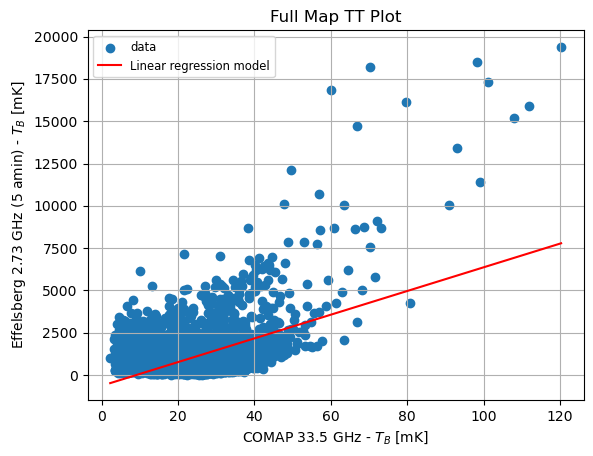


GRADIENT, INTERCEPT, SPECTRAL INDEX VS LONGITUDE - COMAP 33.5 GHz vs Effelsberg 2.73 GHz (5 amin)

Mean gradient =  520.5810 ±  0.0111
Mean spectral index = -1.8890 ±  0.2584
Mean intercept = -9840.8905 ±  0.0025


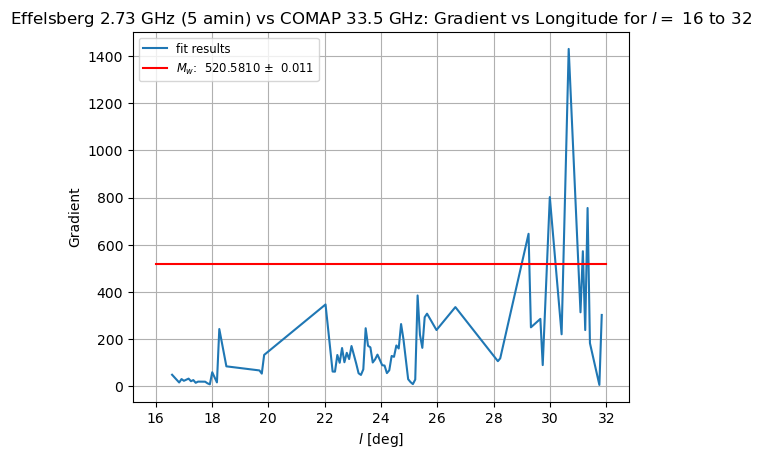

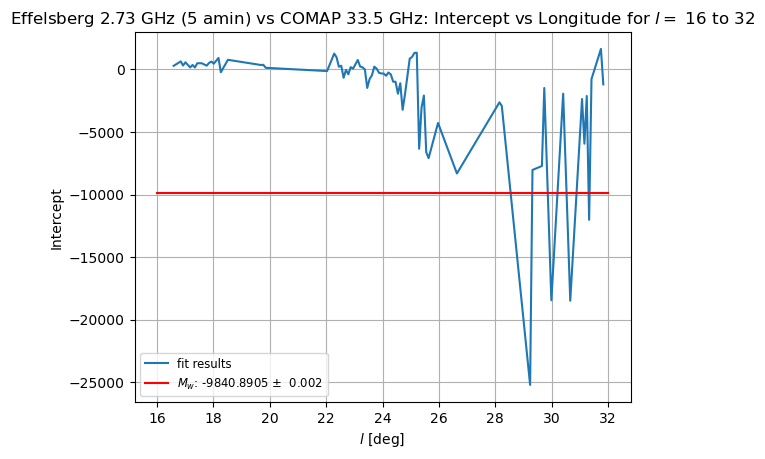

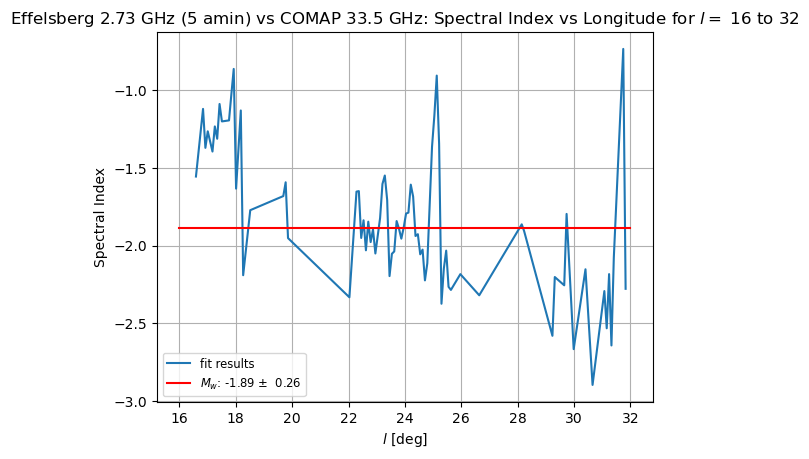


TT PLOT LATTICE - COMAP 33.5 GHz vs Effelsberg 2.73 GHz (5 amin)

Note: The axis labels are out of order but correctly identify each subplot
(7,)
(1,)


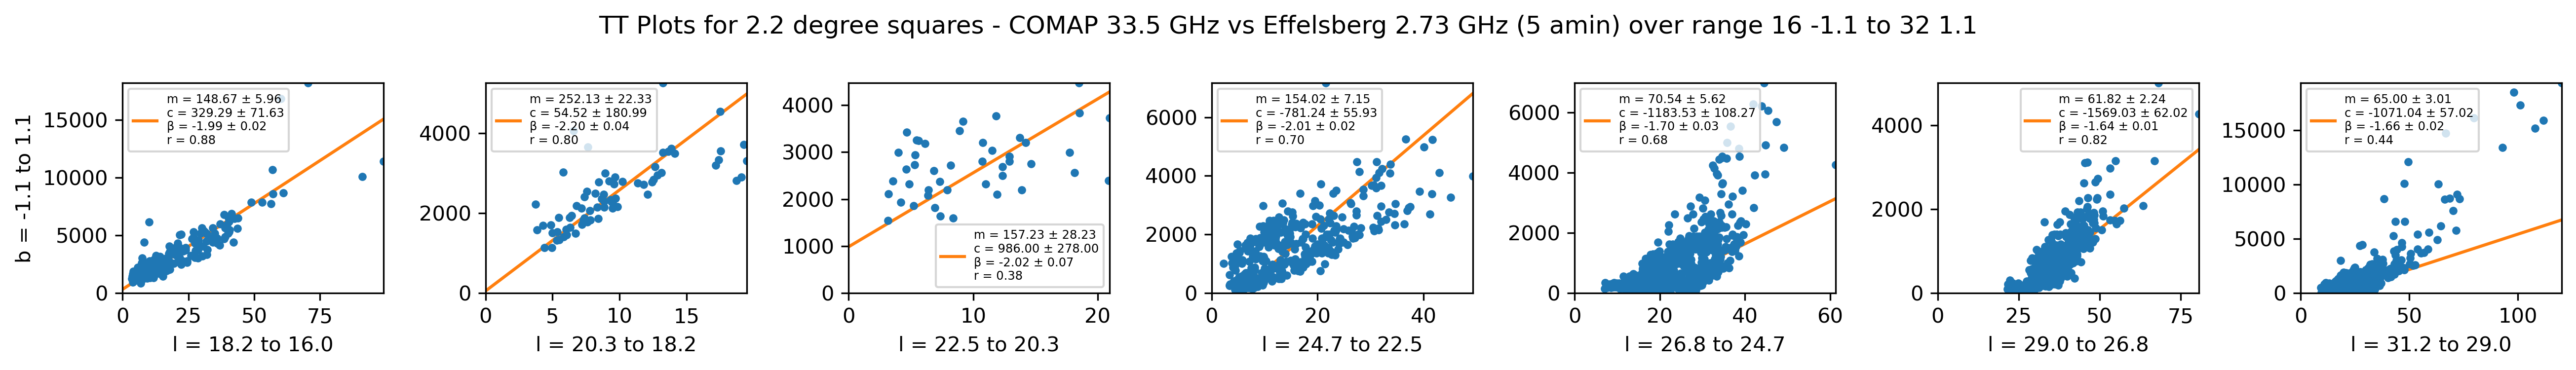

In [857]:
# --- MAIN CODE ---

# SPECIFIC PAIR OF MAPS

map1_title = "COMAP 33.5 GHz"
map2_title = "Effelsberg 2.73 GHz (5 amin)"

main(map1_title, map2_title, show_plots=True)

# # OR: LOOP OVER ALL UNIQUE PAIRS OF MAPS (use with caution!)

# map_titles = ( # add more as needed
#     list(COMAP_MAPS.keys()) + 
#     list(EFFELSBERG_MAPS.keys()) + 
#     list(GDIGS_MAPS.keys()) + 
#     list(NOBEYAMA_MAPS.keys()) + 
#     list(SINO_GERMAN_MAPS.keys()) +
#     list(AKARI_MAPS.keys)
# )

# for i, map1_title in enumerate(map_titles):
#     for j, map2_title in enumerate(map_titles):
#         if i < j:
#             main(map1_title, map2_title, show_plots=False)

